# 使用块网络（VGG）
---
## 环境配置

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import numpy as np
import pypto
import torch
import torch_npu
import torchvision
from torch import nn
device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
mode = pypto.RunMode.NPU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear
from src.PyPTODropoutModule import PyPTODropout
from src.D2LFunction import *
from src.AnswerUtlis import *
from src import Models
import torchinfo

---

&emsp;&emsp;VGG 模型的卷积层部分是由若干 `vgg_block` 串联而成，每个 `vgg_block` 内部由若干卷积层 + 一个最大汇聚层组成。下面以 `vgg11` 为例展示其网络结构：

<div style="border: solid 16px #f1f1f8; text-align: center; background-color: #f6f7f9">
<img src="../images/ch07-1-2-vgg.png" style="width: 400px">
<p style="margin: 12px 0 4px 0; font-size: 0.9em; color: #555; text-align: center;">VGG网络结构</p>
</div>
<br />

In [2]:
class VGGBlock(nn.Module):
    def __init__(self, num_convs, in_channels, out_channels):
        super().__init__()
        layers = []
        for _ in range(num_convs):
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU())
            in_channels = out_channels
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

vgg11 = Models.vgg11()
vgg11.print_layers()

In Sequential:
Conv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
MaxPool2d output shape:	 torch.Size([1, 64, 112, 112])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
MaxPool2d output shape:	 torch.Size([1, 128, 56, 56])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
MaxPool2d output shape:	 torch.Size([1, 256, 28, 28])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
Conv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
MaxPool2d output shape:	 torch.Size([1, 512, 14, 14])
-------------------
In Sequential:
Conv2d output shape:	 

In [3]:
class VGGBlock_pypto(nn.Module):
    def __init__(self, num_convs, in_channels, out_channels, device='npu:0'):
        super().__init__()
        layers = []
        for _ in range(num_convs):
            layers.append(PyPTOConv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=True, device=device))
            layers.append(nn.ReLU())
            in_channels = out_channels
        layers.append(PyPTOMaxPool2d(kernel_size=2, stride=2))
        self.net = nn.Sequential(*layers).to(device)

    def forward(self, x):
        return self.net(x)

vgg11_pypto = Models.vgg11_pypto()
vgg11_pypto.print_layers()

PyPTOConv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])


PyPTOMaxPool2d output shape:	 torch.Size([1, 64, 112, 112])
-------------------


PyPTOConv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])


PyPTOMaxPool2d output shape:	 torch.Size([1, 128, 56, 56])
-------------------


PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])


...

PyPTOMaxPool2d output shape:	 torch.Size([1, 512, 7, 7])
-------------------
Flatten output shape:	 torch.Size([1, 25088])


PyPTOLinear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])


PyPTODropout output shape:	 torch.Size([1, 4096])


PyPTOLinear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
PyPTODropout output shape:	 torch.Size([1, 4096])


PyPTOLinear output shape:	 torch.Size([1, 10])


---
## 练习 7.2.1

打印层尺寸时，打印结果中只显示8个卷积层而不是11个，信息去哪了？

### 解答

&emsp;&emsp;因为打印时每个 `Sequential` (即 `vgg_block`) 内有若干卷积层 + 1 个汇聚层，整个 VGG-11 网络有5个 `Sequential` 卷积块共8个卷积层，加上3个 `Linear` 全连接层。`ReLU`、`Dropout` 等无参数的层不单独打印。

使用 `torch` 编程进行验证：

In [4]:
vgg11 = Models.vgg11()
vgg11.print_layers()

In Sequential:
Conv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
MaxPool2d output shape:	 torch.Size([1, 64, 112, 112])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
MaxPool2d output shape:	 torch.Size([1, 128, 56, 56])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
MaxPool2d output shape:	 torch.Size([1, 256, 28, 28])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
Conv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
MaxPool2d output shape:	 torch.Size([1, 512, 14, 14])
-------------------
In Sequential:
Conv2d output shape:	 

使用 `PyPTO` 编程进行验证：

In [5]:
vgg11_pypto = Models.vgg11_pypto()
vgg11_pypto.print_layers()

PyPTOConv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
PyPTOMaxPool2d output shape:	 torch.Size([1, 64, 112, 112])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
PyPTOMaxPool2d output shape:	 torch.Size([1, 128, 56, 56])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
PyPTOMaxPool2d output shape:	 torch.Size([1, 256, 28, 28])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
PyPTOConv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
PyPTOMaxPool2d output shape:	 torch.Size([1, 512, 14, 14])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 512, 

---
## 练习 7.2.2

与AlexNet相比，VGG的计算要慢得多，并且需要更多的显存，请分析原因。

### 解答

&emsp;&emsp;原因主要有以下几点：

&emsp;&emsp;1. 网络结构更深，VGG有更多卷积层（11个vs AlexNet 8个）；

&emsp;&emsp;2. 特征图更大，VGG-11 输入 224×224；

&emsp;&emsp;3. 部分卷积块使用更多通道（512），参数更多，FLOPs 更大；

&emsp;&emsp;4. 全连接层输出 4096 维，相比 AlexNet 同样大。

使用 `torch` 编程进行验证：

In [6]:
vgg11 = Models.vgg11()
torchinfo.summary(vgg11, (1, 1, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Sequential: 2-1                   [1, 64, 112, 112]         --
│    │    └─Conv2d: 3-1                  [1, 64, 224, 224]         640
│    │    └─ReLU: 3-2                    [1, 64, 224, 224]         --
│    │    └─MaxPool2d: 3-3               [1, 64, 112, 112]         --
│    └─Sequential: 2-2                   [1, 128, 56, 56]          --
│    │    └─Conv2d: 3-4                  [1, 128, 112, 112]        73,856
│    │    └─ReLU: 3-5                    [1, 128, 112, 112]        --
│    │    └─MaxPool2d: 3-6               [1, 128, 56, 56]          --
│    └─Sequential: 2-3                   [1, 256, 28, 28]          --
│    │    └─Conv2d: 3-7                  [1, 256, 56, 56]          295,168
│    │    └─ReLU: 3-8                    [1, 256, 56, 56]          --
│    

---
## 练习 7.2.3

尝试将Fashion-MNIST数据集图像的高度和宽度从224改为96，这会有什么影响？

### 解答

&emsp;&emsp;将图像缩小到 96×96 后，每层特征图尺寸成比例缩小，模型参数量不变，但计算量显著下降，训练速度加快；同时模型在低分辨率下可能损失部分细节信息，准确率有一定下降。

使用 `torch` 编程进行验证：

**训练:**

In [7]:
import os
pth = '../data/ch07_output/'
Vgg11 = Models.vgg11(coef=4, input_size=224)
train_loader, test_loader = load_data_fashion_mnist(batch_size=64, resize=224)
train_models(Vgg11, train_loader, test_loader, epochs=20, lr=0.05, net_type='Vgg11_224', csv_prefix='ch7_02')
train_loader, test_loader = load_data_fashion_mnist(batch_size=64, resize=96)
Vgg11 = Models.vgg11(coef=4, input_size=96)
train_models(Vgg11, train_loader, test_loader, epochs=20, lr=0.05, net_type='Vgg11_96', csv_prefix='ch7_02')

[Vgg11_96] 训练完成: train_loss=0.0684 ███████░ train_acc=0.9742 ████████ test_acc=0.9218 ███████░ et=06:12


**展示:**

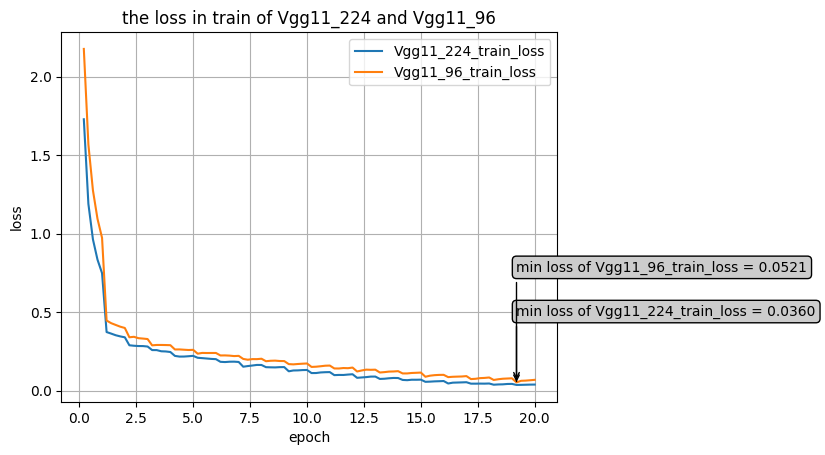

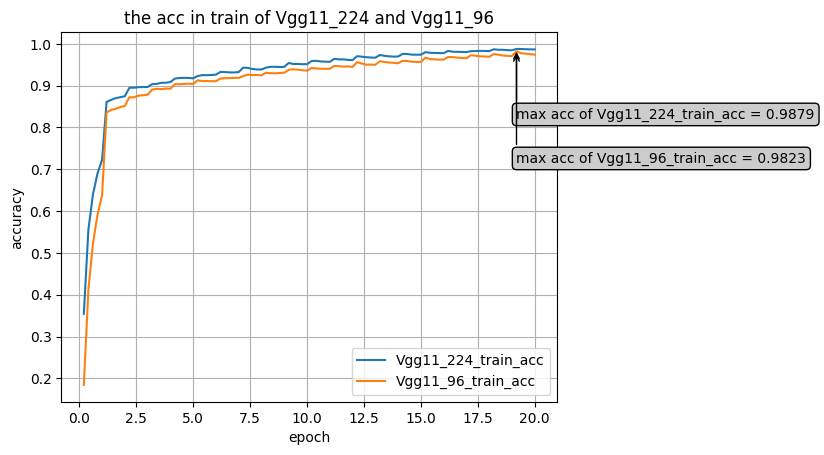

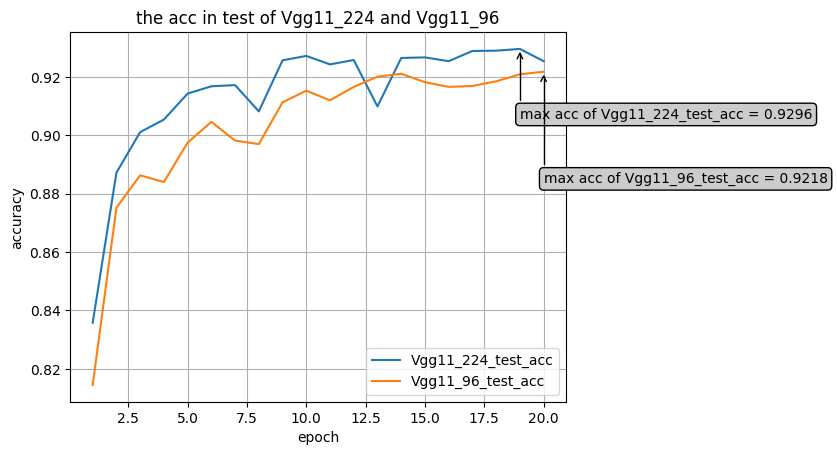

In [8]:
draw_figures(pth = os.path.join(pth, 'ch7_02.csv'),
             label_list=[('Vgg11_224_epoch_train', 'Vgg11_224_train_loss'),
                         ('Vgg11_96_epoch_train', 'Vgg11_96_train_loss')],
             title='the loss in train of Vgg11_224 and Vgg11_96')
draw_figures(pth = os.path.join(pth, 'ch7_02.csv'),
             label_list=[('Vgg11_224_epoch_train', 'Vgg11_224_train_acc'),
                         ('Vgg11_96_epoch_train', 'Vgg11_96_train_acc')],
             title='the acc in train of Vgg11_224 and Vgg11_96')
draw_figures(pth = os.path.join(pth, 'ch7_02_eval.csv'),
             label_list=[('Vgg11_224_epoch_test', 'Vgg11_224_test_acc'),
                         ('Vgg11_96_epoch_test', 'Vgg11_96_test_acc')],
             title='the acc in test of Vgg11_224 and Vgg11_96')

使用 `PyPTO` 编程进行验证：

**训练:**

In [9]:
Vgg11_pypto = Models.vgg11_pypto(coef=4, input_size=224)
train_loader, test_loader = load_data_fashion_mnist(batch_size=64, resize=224)
train_models(Vgg11_pypto, train_loader, test_loader, epochs=20, lr=0.05, net_type='Vgg11_pypto_224', csv_prefix='ch7_02')
Vgg11_pypto_96 = Models.vgg11_pypto(coef=4, input_size=96)
train_loader, test_loader = load_data_fashion_mnist(batch_size=64, resize=96)
train_models(Vgg11_pypto_96, train_loader, test_loader, epochs=20, lr=0.05, net_type='Vgg11_pypto_96', csv_prefix='ch7_02')

[Vgg11_pypto_96] 训练完成: train_loss=0.0728 ███████░ train_acc=0.9730 ████████ test_acc=0.9201 ███████░ et=1:19:03


**展示:**

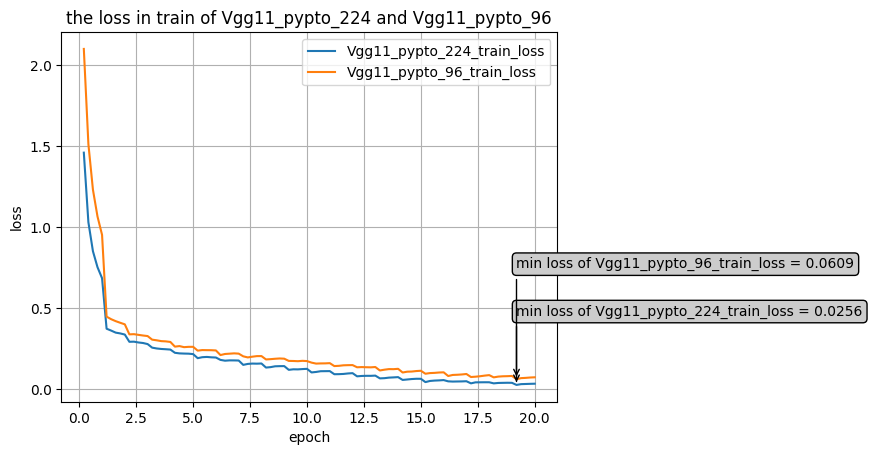

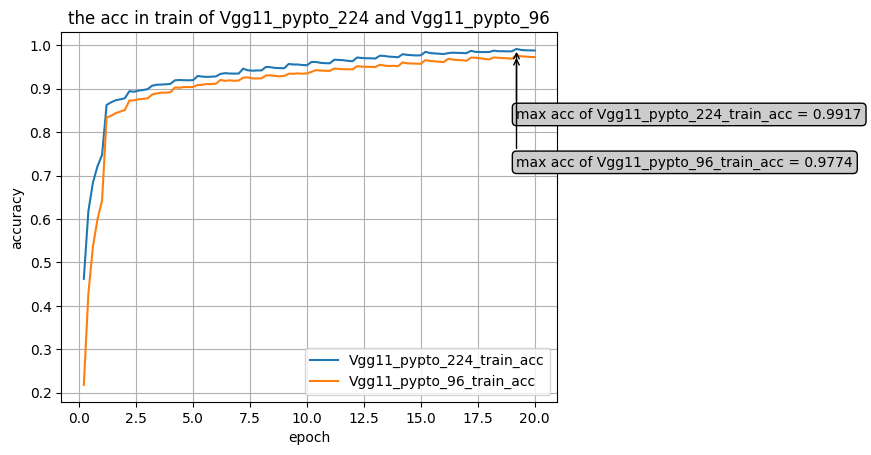

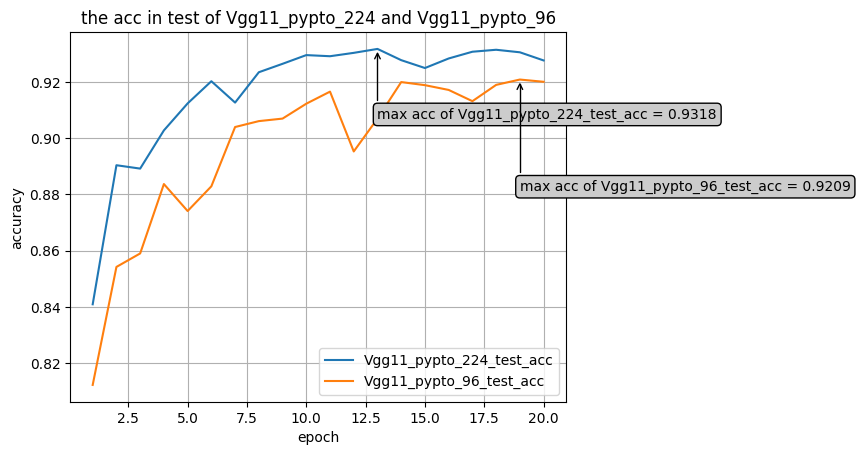

In [10]:
draw_figures(pth = os.path.join(pth, 'ch7_02.csv'),
             label_list=[('Vgg11_pypto_224_epoch_train', 'Vgg11_pypto_224_train_loss'),
                         ('Vgg11_pypto_96_epoch_train', 'Vgg11_pypto_96_train_loss')],
             title='the loss in train of Vgg11_pypto_224 and Vgg11_pypto_96')
draw_figures(pth = os.path.join(pth, 'ch7_02.csv'),
             label_list=[('Vgg11_pypto_224_epoch_train', 'Vgg11_pypto_224_train_acc'),
                         ('Vgg11_pypto_96_epoch_train', 'Vgg11_pypto_96_train_acc')],
             title='the acc in train of Vgg11_pypto_224 and Vgg11_pypto_96')
draw_figures(pth = os.path.join(pth, 'ch7_02_eval.csv'),
             label_list=[('Vgg11_pypto_224_epoch_test', 'Vgg11_pypto_224_test_acc'),
                         ('Vgg11_pypto_96_epoch_test', 'Vgg11_pypto_96_test_acc')],
             title='the acc in test of Vgg11_pypto_224 and Vgg11_pypto_96')

---
## 练习 7.2.4

参考VGG论文中的表1构建其他模型，例如VGG-16或者VGG-19。

### 解答

&emsp;&emsp;参考论文 https://arxiv.org/pdf/1409.1556.pdf，VGG 不同版本均由相同的 `vgg_block` 结构堆叠而成，区别在于每个块中的层数与通道数。下面以 VGG-16 和 VGG-19 为例展示其结构：

<div style="border: solid 16px #f1f1f8; text-align: center; background-color: #f6f7f9">
<img src="../images/ch07-1-2-vgg.png" style="width: 400px">
<p style="margin: 12px 0 4px 0; font-size: 0.9em; color: #555; text-align: center;">VGG网络结构</p>
</div>
<br />

使用 `torch` 编程进行验证：

In [11]:
print("----------Vgg16 models-----------")
Vgg16 = Models.vgg16()
Vgg16.print_layers()
print("----------Vgg19 models-----------")
Vgg19 = Models.vgg19()
Vgg19.print_layers()

----------Vgg16 models-----------


In Sequential:
Conv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
Conv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
MaxPool2d output shape:	 torch.Size([1, 64, 112, 112])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
Conv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
MaxPool2d output shape:	 torch.Size([1, 128, 56, 56])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
MaxPool2d output shape:	 torch.Size([1, 256, 28, 28])
-------------------
In Sequential:
Conv2

In Sequential:
Conv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
Conv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
MaxPool2d output shape:	 torch.Size([1, 64, 112, 112])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
Conv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
MaxPool2d output shape:	 torch.Size([1, 128, 56, 56])
-------------------
In Sequential:
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
Conv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56,

使用 `PyPTO` 编程进行验证：

In [12]:
print("----------Vgg16 PyPTO models-----------")
Vgg16_pypto = Models.vgg16_pypto()
Vgg16_pypto.print_layers()
print("----------Vgg19 PyPTO models-----------")
Vgg19_pypto = Models.vgg19_pypto()
Vgg19_pypto.print_layers()

----------Vgg16 PyPTO models-----------


PyPTOConv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])


PyPTOConv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
PyPTOMaxPool2d output shape:	 torch.Size([1, 64, 112, 112])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])


PyPTOConv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
PyPTOMaxPool2d output shape:	 torch.Size([1, 128, 56, 56])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
PyPTOMaxPool2d output shape:	 torch.Size([1, 256, 28, 28])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
PyPTOConv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
PyPTOConv2d output shape:	 torch.Size([1, 512, 28, 28])
ReLU output shape:	 torch.Size([1, 512, 28, 28])
PyPTOMaxPool2d output shape:	 torch.Size([1, 512, 14, 14])
-------------------
PyPTOConv2d output shape

PyPTOConv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
PyPTOConv2d output shape:	 torch.Size([1, 64, 224, 224])
ReLU output shape:	 torch.Size([1, 64, 224, 224])
PyPTOMaxPool2d output shape:	 torch.Size([1, 64, 112, 112])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
PyPTOConv2d output shape:	 torch.Size([1, 128, 112, 112])
ReLU output shape:	 torch.Size([1, 128, 112, 112])
PyPTOMaxPool2d output shape:	 torch.Size([1, 128, 56, 56])
-------------------
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256, 56, 56])
PyPTOConv2d output shape:	 torch.Size([1, 256, 56, 56])
ReLU output shape:	 torch.Size([1, 256

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#](https://datawhalechina.github.io/d2l-ai-solutions-manual/#)